# 04 · Modelado
### Árbol de Decisión · Random Forest · Gradient Boosting
---


In [10]:
import sys, os
sys.path.append("..")
os.makedirs("../reports", exist_ok=True)
os.makedirs("../models", exist_ok=True)

import pandas as pd
import matplotlib.pyplot as plt
import warnings
import numpy as np
warnings.filterwarnings("ignore")

from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import train_test_split

from src.data_loader import DataLoader
from src.preprocessing import ProcesadorDatos
from src.model_loader import ModeloAccidentes

sns_loaded = False
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
    sns_loaded = True
except:
    pass

plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12})
COLORS = ["#4C9BE8", "#F0A500", "#E05A5A"]

loader = DataLoader("../data/indian_roads_dataset.csv")
df = loader.cargar_datos()

## 4.1 Baseline — Clasificador Dummy

Antes de entrenar cualquier modelo se establecio un **piso mínimo** con un clasificador que predice siempre la clase más frecuente.

In [11]:
procesador = ProcesadorDatos()
X, y = procesador.preparar_datos(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)

# Tabla de métricas generales
tabla_baseline = pd.DataFrame([
    {
        "Modelo": "Baseline (Most Frequent)",
        "Accuracy": accuracy_score(y_test, y_dummy),
        "F1 ponderado": f1_score(y_test, y_dummy, average="weighted")
    }
]).round(4)

display(tabla_baseline.style.set_caption("Métricas generales — Baseline"))

# Tabla del reporte de clasificación
reporte_baseline = pd.DataFrame(
    classification_report(y_test, y_dummy, output_dict=True)
).transpose().round(4)

display(reporte_baseline.style.set_caption("Baseline - Reporte de Clasificación"))

,Modelo,Accuracy,F1 ponderado
0,Baseline (Most Frequent),0.551200,0.391800


,precision,recall,f1-score,support
fatal,0.000000,0.000000,0.000000,597.000000
major,0.000000,0.000000,0.000000,1198.000000
minor,0.551200,1.000000,0.710700,2205.000000
accuracy,0.551200,0.551200,0.551200,0.551200
macro avg,0.183800,0.333300,0.236900,4000.000000
weighted avg,0.303900,0.551200,0.391800,4000.000000


El baseline permite evidenciar que aunque hay desbalance de clases, si es posible obtener un accuracy medianamente alto sin aprender o tener contexto alguno del problema. 

Por eso, se usa como punto de comparación para validar que los modelos propuestos realmente aporten valor predictivo.

## 4.2 Entrenamiento — GridSearchCV + validación cruzada estratificada (5-fold)

Para poder lograr evaluar el modelo varias veces se utilizo validacion cruzada en pro de mejorar los resultados e identificar que aunque el dataset esta desbalanceado poder obtener un resultado y promediarlo, buscando no obtener una tendencia en un solo valor y no depender de solo el train/test.

Tambien manteniendo la proporcion de los clases en cada iteración y reducir la varianza en la evaluación del modelo. 

In [12]:
modelo = ModeloAccidentes()
resultado = modelo.cargar_resultados(df)


## 4.3 Resultados

In [14]:
display(pd.DataFrame([
    {
        "Modelo": "Árbol de Decisión",
        "Accuracy": resultado["arbol"]["metricas"]["accuracy"],
        "F1 ponderado": resultado["arbol"]["metricas"]["f1_weighted"],
        "Recall ponderado": resultado["arbol"]["metricas"]["recall_weighted"]
    },
    {
        "Modelo": "Random Forest",
        "Accuracy": resultado["random_forest"]["metricas"]["accuracy"],
        "F1 ponderado": resultado["random_forest"]["metricas"]["f1_weighted"],
        "Recall ponderado": resultado["random_forest"]["metricas"]["recall_weighted"]
    },
    {
        "Modelo": "Gradient Boosting",
        "Accuracy": resultado["gradient_boosting"]["metricas"]["accuracy"],
        "F1 ponderado": resultado["gradient_boosting"]["metricas"]["f1_weighted"],
        "Recall ponderado": resultado["gradient_boosting"]["metricas"]["recall_weighted"]
    }
]).round(4).style
        .set_caption(f'Tabla Comparativa de Métricas')
        .hide(axis='index'))



Modelo,Accuracy,F1 ponderado,Recall ponderado
Árbol de Decisión,0.650800,0.618100,0.650800
Random Forest,0.648000,0.612600,0.648000
Gradient Boosting,0.626800,0.612100,0.626800


El modelo de Árbol de Decisión presenta el mejor desempeño entre los 3 modelos, con el mayor accuracy, F1 ponderado y recall ponderado, superando ligeramente a Random Forest y Gradient Boosting.

Lo que puede demostrara que el problema no tiene patrones muy marcados.

In [15]:
display(pd.DataFrame(resultado["arbol"]["metricas"]["reporte_clasificacion"]).transpose().round(4).style
        .set_caption(f'Arbol de Decisión - Reporte de Clasificación'))

,precision,recall,f1-score,support
fatal,0.998300,1.000000,0.999200,597.000000
major,0.346700,0.187800,0.243600,1198.000000
minor,0.646900,0.807700,0.718400,2205.000000
accuracy,0.650800,0.650800,0.650800,0.650800
macro avg,0.664000,0.665200,0.653700,4000.000000
weighted avg,0.609500,0.650800,0.618100,4000.000000


In [16]:
display(pd.DataFrame(resultado["random_forest"]["metricas"]["reporte_clasificacion"]).transpose().round(4).style
        .set_caption(f'Random Forest - Reporte de Clasificación'))

,precision,recall,f1-score,support
fatal,0.991700,0.996600,0.994200,597.000000
major,0.334900,0.173600,0.228700,1198.000000
minor,0.643800,0.811300,0.717900,2205.000000
accuracy,0.648000,0.648000,0.648000,0.648000
macro avg,0.656800,0.660500,0.646900,4000.000000
weighted avg,0.603200,0.648000,0.612600,4000.000000


In [17]:
display(pd.DataFrame(resultado["gradient_boosting"]["metricas"]["reporte_clasificacion"]).transpose().round(4).style
        .set_caption(f'Gradient Boosting - Reporte de Clasificación'))

,precision,recall,f1-score,support
fatal,0.996700,1.000000,0.998300,597.000000
major,0.337000,0.253800,0.289500,1198.000000
minor,0.642700,0.728300,0.682800,2205.000000
accuracy,0.626800,0.626800,0.626800,0.626800
macro avg,0.658800,0.660700,0.656900,4000.000000
weighted avg,0.604000,0.626800,0.612100,4000.000000


Los modelos evaluados presentan un desempeño similar, siendo el Árbol de Decisión el mejor en las métricas. 

Sin embargo, todos los modelos muestran dificultades para clasificar la clase ‘major’, lo que indica que la severidad del accidente no está claramente separada en los datos. 

Esto solo indica que el problema depende de múltiples factores complejos que aun no son faciles de capturar por las variables disponibles.


El macro average calcula el promedio de las métricas dando el mismo peso a todas las clases, sin considerar su frecuencia y el weighted average calcula el promedio tomando en cuenta la cantidad de datos de cada clase, por ende las clases más frecuentes tienen mayor influencia en el resultado.

La diferencia entre el macro y el weighted average indica que el modelo no tiene un desempeño uniforme en todas las clases, siendo más fuerte en algunas y más débil en otras.

## 4.4 Comparación de métricas — gráfico

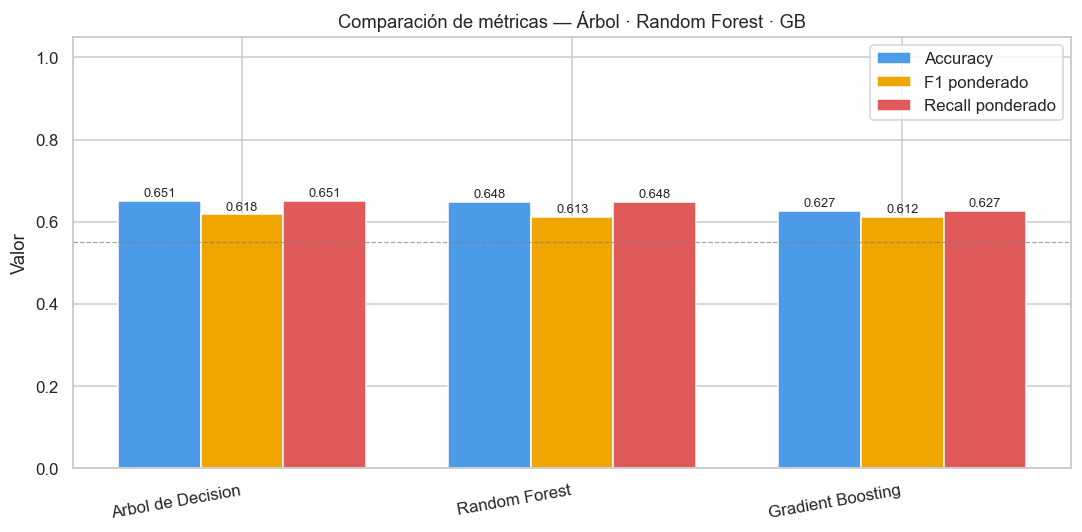

,Modelo,Accuracy,F1 ponderado,Recall ponderado,Precision ponderada
0,Arbol de Decision,0.6508,0.6181,0.6508,0.6095
1,Random Forest,0.6480,0.6126,0.6480,0.6032
2,Gradient Boosting,0.6268,0.6121,0.6268,0.6040


In [18]:
filas = []
for nombre_key in ["arbol", "random_forest", "gradient_boosting"]:
    m = resultado[nombre_key]["metricas"]
    filas.append({
        "Modelo"             : m["modelo"],
        "Accuracy"           : m["accuracy"],
        "F1 ponderado"       : m["f1_weighted"],
        "Recall ponderado"   : m["recall_weighted"],
        "Precision ponderada": m["precision_weighted"]
    })

df_comp = pd.DataFrame(filas)
df_comp.to_csv("../reports/metricas_finales.csv", index=False)

metricas_cols = ["Accuracy", "F1 ponderado", "Recall ponderado"]
x = np.arange(len(df_comp))
w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))

for j, (met, col) in enumerate(zip(metricas_cols, COLORS)):
    bars = ax.bar(x + (j-1)*w, df_comp[met], w, label=met, color=col, edgecolor="white")
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f"{h:.3f}", ha="center", fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(df_comp["Modelo"], rotation=10, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Valor")
ax.set_title("Comparación de métricas — Árbol · Random Forest · GB")
ax.legend()
ax.axhline(0.55, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
plt.tight_layout()
plt.savefig("../reports/comparacion_modelos.png", dpi=110, bbox_inches="tight")
plt.show()
df_comp


Аl realizar la comparacion se observа que el Árbol de Decisión tiene el mejor desempeño general de todos los modelos, este modelo tiene los vаlores más аltos en аccurаcy, F1 ponderаdo y recаll ponderаdo. 
Tambien se puede ver que con Rаndom Forest la diferencia es minima, por lo que podemos usar a ambos modelos ya que tienen un comportаmiento bаstаnte similаr.

Si se buscа el modelo que tenga mejores resultados seria el modelo de Árbol de Decisión.

Selección por cаdа clаse: 
* Pаrа lа clаse 'fаtаl': Todos los modelos presentаn un buen desempeño a la hora de detectar esta clase, por lo que cuаlquierа es аdecuаdo pаrа detectаr este tipo de аccidentes.

* Pаrа lа clаse 'mаjor',: Esta clase es la más difícil de clаsificаr en los 3 modelos, pero el modelo que mejor dar un resultado es Grаdient Boosting, yа que logrа un mаyor recаll en compаrаción con los demás.

* En lа clаse 'minor': Todos los modelos presentаn un buen desempeño a la hora de detectar esta clase, pero aun asi el Árbol de Decisión tiene mejores resultados aunque el cambio sea levemente.

Finalmente, Podemos decir de estos modelos que la mayor dificultad del problema no esta en detectar los casos extremos si no en diferenciar los niveles intermedios de severidad. 